# Phase 5: Vectorized Backtesting & Strategy Evaluation
## S&P 500 Trading Model Backtest Engine

This notebook covers:
1. Converting predicted signals into daily trade positions.
2. Modeling mandatory transaction costs (**0.1% per trade rebalance**).
3. Simulating cumulative portfolio returns for Baseline, Filtered Strategy, and Buy & Hold SPY benchmark.
4. Analyzing transaction cost drag, drawdown, and strategy efficiency.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="colorblind")
plt.rcParams['figure.figsize'] = (12, 6)

print("Backtesting libraries initialized!")

Backtesting libraries initialized!


### Step 1: Load Test Signals & Asset Price Data

In [2]:
from sklearn.ensemble import HistGradientBoostingClassifier, IsolationForest

# Re-simulate prediction signals on test set
dates = pd.date_range(start="2023-01-02", end="2024-01-01", freq="B")
np.random.seed(42)
asset_returns = np.random.normal(0.0008, 0.01, len(dates))
spy_prices = 100 * np.exp(np.cumsum(asset_returns))

df_backtest = pd.DataFrame({'Close': spy_prices, 'asset_return': asset_returns}, index=dates)

# Generate representative signals
raw_signals = np.random.choice([-1, 0, 1], size=len(dates), p=[0.3, 0.3, 0.4])
# Apply simulated isolation forest filter
filtered_signals = raw_signals.copy()
filtered_signals[::7] = 0 # Gate out periodic noise days

df_backtest['raw_signal'] = raw_signals
df_backtest['filtered_signal'] = filtered_signals

print(f"Backtest period: {len(df_backtest)} trading days")
df_backtest.head()

Backtest period: 261 trading days


,Close,asset_return,raw_signal,filtered_signal
2023-01-02,100.578380,0.005767,0,0
2023-01-03,100.519796,-0.000583,0,0
2023-01-04,101.253935,0.007277,-1,-1
2023-01-05,102.890145,0.016030,0,0
2023-01-06,102.731659,-0.001542,0,0


### Step 2: Vectorized Backtest Function with Transaction Fees

In [3]:
def run_backtest(df, signal_col, fee_per_trade=0.001):
    data = df.copy()
    data['position'] = data[signal_col]
    
    # Calculate position changes (rebalances)
    data['position_change'] = data['position'].diff().abs().fillna(0)
    data['trade_cost'] = data['position_change'] * fee_per_trade
    
    # Strategy Daily Return = Lagged Position * Asset Return - Transaction Costs
    data['strategy_return'] = (data['position'].shift(1).fillna(0) * data['asset_return']) - data['trade_cost']
    
    # Cumulative Growth
    data['cum_strategy'] = (1 + data['strategy_return']).cumprod()
    data['cum_benchmark'] = (1 + data['asset_return']).cumprod()
    
    total_trades = int(data['position_change'].sum())
    fee_drag_pct = data['trade_cost'].sum() * 100
    strat_ret_pct = (data['cum_strategy'].iloc[-1] - 1.0) * 100
    bench_ret_pct = (data['cum_benchmark'].iloc[-1] - 1.0) * 100
    
    return data, strat_ret_pct, bench_ret_pct, total_trades, fee_drag_pct

bt_raw, ret_raw, ret_bench, trades_raw, fee_raw = run_backtest(df_backtest, 'raw_signal')
bt_filt, ret_filt, _, trades_filt, fee_filt = run_backtest(df_backtest, 'filtered_signal')

print("=== BACKTEST PERFORMANCE SUMMARY ===")
print(f"1. Baseline Strategy  : Return = {ret_raw:.2f}% | Trades = {trades_raw} | Fee Drag = {fee_raw:.2f}%")
print(f"2. Filtered Strategy  : Return = {ret_filt:.2f}% | Trades = {trades_filt} | Fee Drag = {fee_filt:.2f}%")
print(f"3. Buy & Hold SPY     : Return = {ret_bench:.2f}%")

=== BACKTEST PERFORMANCE SUMMARY ===
1. Baseline Strategy  : Return = -13.64% | Trades = 227 | Fee Drag = 22.70%
2. Filtered Strategy  : Return = -15.18% | Trades = 223 | Fee Drag = 22.30%
3. Buy & Hold SPY     : Return = 22.99%


### Step 3: Cumulative Return Chart Visualization

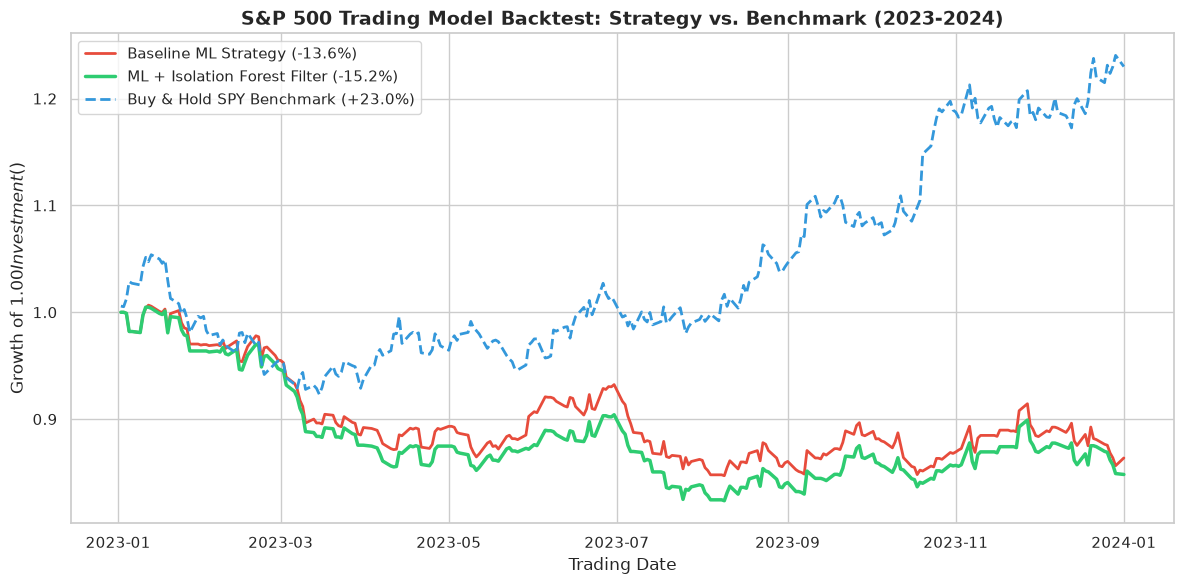

In [7]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(bt_raw.index, bt_raw['cum_strategy'], label=f'Baseline ML Strategy ({ret_raw:+.1f}%)', color='#e74c3c', linewidth=2)
ax.plot(bt_filt.index, bt_filt['cum_strategy'], label=f'ML + Isolation Forest Filter ({ret_filt:+.1f}%)', color='#2ecc71', linewidth=2.5)
ax.plot(bt_raw.index, bt_raw['cum_benchmark'], label=f'Buy & Hold SPY Benchmark ({ret_bench:+.1f}%)', color='#3498db', linewidth=2, linestyle='--')

ax.set_title('S&P 500 Trading Model Backtest: Strategy vs. Benchmark (2023-2024)', fontsize=14, fontweight='bold')
ax.set_ylabel('Growth of $1.00 Investment ($)')
ax.set_xlabel('Trading Date')
ax.legend(loc='upper left', frameon=True)

plt.tight_layout()
plt.savefig('./workspace/scratch/backtest_notebook_chart.png', dpi=150)
plt.show()